# Sudoku extreme-only study

Sister notebook to `sudoku_hard_only_study.ipynb`. The hard cohort already showed a
monotone BPTT − StopGrad gradient with difficulty (BF-tail +4 pp → heuristic-Advanced
+6 pp → heuristic-Master +19 pp at n=6). The Master result was the only weak link
because of small-n; this notebook is the dedicated extreme-tier eval that fixes that.

Cohort: `submit_sudoku_qualitative_dumps.sh HARD_FILTER=extreme MAX_EXAMPLES=1500`
selects puzzles satisfying `rating >= 100` ∨ `num_steps_solver >= 12` ∨ any
`Master` (X-Wing / Swordfish / Jellyfish / Forcing Chain) strategy. With the
1,500-puzzle cap and ~4,500 extreme puzzles in the test split, this is a ~33%
sample of the available pool — enough to attach a CI to per-strategy gains.

Refinements over the hard notebook:

1. **Cohort definition prints the per-clause counts** (rating, num_steps, tier),
   not just the OR. Last time the OR pulled in lots of long-but-easy BF puzzles;
   this notebook surfaces that breakdown so you can argue about which clause is
   carrying the weight.
2. **F4' is tier-stratified**: legality rate by hardest-strategy tier, so the
   legality story is decomposed alongside the EM story.
3. **F3' drops `prefix_jaccard_at_20`** because most loopholing trajectories
   never reach 20 fills; the metric saturates at 0.
4. **Per-stratum table is the headline figure**: this is where the extreme dump
   actually pays off (Master-tier should now have n in the hundreds, not 6).

Sections:

1. Bootstrap & load
2. Extreme-cohort definition (per-clause + AND/OR diagnostics)
3. F1' — Pareto on extreme puzzles only
4. F2' — paired Δ BPTT − StopGrad with bootstrap CIs
5. F4' — legality, *tier-stratified*
6. F3' — solver alignment, paired (Spearman, prefix-J@5/10)
7. Coverage-gated matched-NFE
8. Per-stratum table — heuristic-only Advanced/Master + BF rating-tail


In [1]:
import sys
from pathlib import Path

def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / 'doublebackprop' / 'sudoku_analysis.py').is_file():
            return p
    raise RuntimeError('Run from inside the double-backprop repo')

_root = _repo_root()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from doublebackprop import sudoku_analysis as sa

PARQUET_EXTREME = _root / 'outputs' / 'sudoku_analysis_extreme' / 'sudoku_analysis_extreme.parquet'
PARQUET_HARD    = _root / 'outputs' / 'sudoku_analysis_hard' / 'sudoku_analysis_hard.parquet'
PARQUET_FULL    = _root / 'outputs' / 'sudoku_analysis' / 'sudoku_analysis.parquet'
FIGS = _root / 'outputs' / 'sudoku_analysis_extreme' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)
print('parquet (extreme):', PARQUET_EXTREME, PARQUET_EXTREME.exists())
print('parquet (hard):   ', PARQUET_HARD, PARQUET_HARD.exists())
print('parquet (full):   ', PARQUET_FULL, PARQUET_FULL.exists())
print('figs:             ', FIGS)

parquet (extreme): /work/pi_mccallum_umass_edu/brozonoyer_umass_edu/double-backprop/outputs/sudoku_analysis_extreme/sudoku_analysis_extreme.parquet True
parquet (hard):    /work/pi_mccallum_umass_edu/brozonoyer_umass_edu/double-backprop/outputs/sudoku_analysis_hard/sudoku_analysis_hard.parquet True
parquet (full):    /work/pi_mccallum_umass_edu/brozonoyer_umass_edu/double-backprop/outputs/sudoku_analysis/sudoku_analysis.parquet True
figs:              /work/pi_mccallum_umass_edu/brozonoyer_umass_edu/double-backprop/outputs/sudoku_analysis_extreme/figures


In [2]:
OBJECTIVE_ORDER = [
    'mlm_uniform',
    'puma_no_loopholing',
    'puma_loopholing_stop_grad',
    'puma_loopholing_bptt',
]
OBJECTIVE_LABEL = {
    'mlm_uniform': 'Uniform MLM',
    'puma_no_loopholing': 'No-Relay (PUMA only)',
    'puma_loopholing_stop_grad': 'Relay (StopGrad)',
    'puma_loopholing_bptt': 'LEAR (BPTT)',
}
OBJECTIVE_COLOR = {
    'mlm_uniform': '#888888',
    'puma_no_loopholing': '#1f77b4',
    'puma_loopholing_stop_grad': '#ff7f0e',
    'puma_loopholing_bptt': '#d62728',
}
STRATEGY_ORDER = ['Easy', 'Medium', 'Advanced', 'Master', 'BruteForce']

def _load_one(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    if 'seed' not in df.columns:
        df['seed'] = pd.NA
    df['seed'] = df['seed'].astype('Int64')
    df['hardest_strategy'] = pd.Categorical(
        df['hardest_strategy'], categories=STRATEGY_ORDER, ordered=True
    )
    df['objective'] = pd.Categorical(
        df['objective'], categories=OBJECTIVE_ORDER, ordered=True
    )
    return df

if PARQUET_EXTREME.exists():
    df_raw = _load_one(PARQUET_EXTREME)
    SOURCE = 'extreme-dump'
elif PARQUET_HARD.exists():
    df_raw = _load_one(PARQUET_HARD)
    SOURCE = 'hard-dump (fallback)'
elif PARQUET_FULL.exists():
    df_raw = _load_one(PARQUET_FULL)
    SOURCE = 'full-dump (filtered in-memory)'
else:
    raise FileNotFoundError('No parquet found; re-run dump first.')
print('loaded source:', SOURCE)
print('rows:', len(df_raw),
      '| unique runs:', df_raw['run_id'].nunique(),
      '| unique tau:', sorted(df_raw['tau'].unique()),
      '| unique seeds:', sorted([int(s) for s in df_raw['seed'].dropna().unique().tolist()]),
      '| unique puzzles:', df_raw['puzzle_hash'].nunique())
df_raw['hardest_strategy'].value_counts(dropna=False).reindex(STRATEGY_ORDER, fill_value=0)

loaded source: extreme-dump
rows: 231000 | unique runs: 22 | unique tau: [np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.25), np.float64(0.35), np.float64(0.45)] | unique seeds: [1, 2, 3] | unique puzzles: 1500


hardest_strategy
Easy             308
Medium          4928
Advanced       17248
Master          3080
BruteForce    205436
Name: count, dtype: int64

## Extreme-cohort definition

Same three knobs as `sudoku_hard_only_study.ipynb`, but the defaults track
`sudoku_extreme_extreme_filter_fn`:

- `RATING_MIN = 100`: top ~1% of the test split by rating (p99 = 100).
- `NUM_STEPS_MIN = 12`: top ~1% by solver chain length.
- `KEEP_TIERS = {'Master'}`: puzzles whose hardest tier is Master (X-Wings,
  Swordfish, Jellyfish, Forcing Chain). Advanced is *not* in the default extreme
  set — those are in the hard cohort.

After dropping the diverged seed tuples we also report **per-clause counts** so
you can see whether the cohort is being carried by the rating tail, the
num-steps tail, or the strategy tier — last time the OR pulled in long-but-easy
BF-tier puzzles, so this diagnostic catches that.

In [3]:
RATING_MIN = 100
NUM_STEPS_MIN = 12
KEEP_TIERS = {'Master'}
DIVERGED_SEED_TUPLES = [
    ('mlm_uniform', 'tied', 3),
    ('puma_loopholing_stop_grad', 'tied', 1),
]

df = df_raw.copy()
for obj, ty, sd in DIVERGED_SEED_TUPLES:
    mask = (
        (df['objective'] == obj)
        & (df['embed_tying'] == ty)
        & (df['seed'] == sd)
    )
    df = df[~mask].copy()

if SOURCE == 'extreme-dump':
    df_hard = df  # already filtered server-side; every row is extreme.
else:
    rating_ok = df['rating'].fillna(-1) >= RATING_MIN
    steps_ok = df['num_steps_solver'].fillna(-1) >= NUM_STEPS_MIN
    tier_ok = df['hardest_strategy'].astype(str).isin(KEEP_TIERS)
    keep_hashes = df.loc[rating_ok | steps_ok | tier_ok, 'puzzle_hash'].unique()
    df_hard = df[df['puzzle_hash'].isin(keep_hashes)].copy()

n_puzzles_hard = df_hard['puzzle_hash'].nunique()
n_puzzles_full = df_raw['puzzle_hash'].nunique()
COHORT_LABEL = (
    f'extreme cohort: {n_puzzles_hard}/{n_puzzles_full} puzzles | '
    f'(rating>={RATING_MIN}) | (num_steps_solver>={NUM_STEPS_MIN}) | '
    f'tier in {sorted(KEEP_TIERS)} | source={SOURCE}'
)
print(COHORT_LABEL)
print('\nper-tier puzzle counts (extreme):')
print(df_hard.drop_duplicates('puzzle_hash')['hardest_strategy']
      .value_counts().reindex(STRATEGY_ORDER, fill_value=0))
print('\nrating quantiles (extreme):')
print(df_hard.drop_duplicates('puzzle_hash')['rating']
      .quantile([0.5, 0.75, 0.9, 0.99, 1.0]).round(1).to_dict())
print('\nnum_steps_solver quantiles (extreme):')
print(df_hard.drop_duplicates('puzzle_hash')['num_steps_solver']
      .quantile([0.5, 0.75, 0.9, 0.99, 1.0]).round(1).to_dict())

# Per-clause diagnostics: how many puzzles in the cohort would each clause
# accept on its own? Useful because OR makes it impossible to attribute the
# cohort's makeup to any single criterion.
unique_puzzles = df_hard.drop_duplicates('puzzle_hash')[[
    'puzzle_hash', 'rating', 'num_steps_solver', 'hardest_strategy', 'strategies_used',
]]


def _has_master_strategy(strats):
    if strats is None:
        return False
    try:
        s = list(strats)
    except TypeError:
        return False
    master = {'X-Wing', 'X-Wings', 'Swordfish', 'Jellyfish', 'Jellyfishes',
              'Forcing Chain', 'Forcing Chains'}
    return any(str(x) in master for x in s)


unique_puzzles = unique_puzzles.assign(
    rating_ok=unique_puzzles['rating'].fillna(-1) >= RATING_MIN,
    steps_ok=unique_puzzles['num_steps_solver'].fillna(-1) >= NUM_STEPS_MIN,
    tier_ok=unique_puzzles['hardest_strategy'].astype(str).isin(KEEP_TIERS),
    master_strat_ok=unique_puzzles['strategies_used'].apply(_has_master_strategy),
)
print('\nper-clause counts (each clause counts puzzles it would accept ALONE):')
for col, name in [
    ('rating_ok', f'rating >= {RATING_MIN}'),
    ('steps_ok', f'num_steps_solver >= {NUM_STEPS_MIN}'),
    ('tier_ok', f'hardest_strategy in {sorted(KEEP_TIERS)}'),
    ('master_strat_ok', 'any Master-tier strategy literally in strategies_used'),
]:
    n = int(unique_puzzles[col].sum())
    print(f'  {name}: {n} ({100 * n / len(unique_puzzles):.1f}%)')

# Pairwise overlap so you can see whether clauses are nested or independent.
print('\npairwise OR-only counts (puzzles each clause uniquely contributes):')
all_ok = unique_puzzles['rating_ok'] | unique_puzzles['steps_ok'] | unique_puzzles['tier_ok']
print(f"  union (rating | steps | tier): {int(all_ok.sum())} (should equal cohort size)")
only_rating = unique_puzzles['rating_ok'] & ~unique_puzzles['steps_ok'] & ~unique_puzzles['tier_ok']
only_steps = ~unique_puzzles['rating_ok'] & unique_puzzles['steps_ok'] & ~unique_puzzles['tier_ok']
only_tier = ~unique_puzzles['rating_ok'] & ~unique_puzzles['steps_ok'] & unique_puzzles['tier_ok']
print(f'  only rating, not steps or tier:   {int(only_rating.sum())}')
print(f'  only steps, not rating or tier:   {int(only_steps.sum())}')
print(f'  only tier, not rating or steps:   {int(only_tier.sum())}')

print('\nrun count per (objective, embed_tying):')
print(df_hard.drop_duplicates('run_id')
      .groupby(['objective', 'embed_tying'], observed=True)
      .size())

extreme cohort: 1500/1500 puzzles | (rating>=100) | (num_steps_solver>=12) | tier in ['Master'] | source=extreme-dump

per-tier puzzle counts (extreme):
hardest_strategy
Easy             2
Medium          32
Advanced       112
Master          20
BruteForce    1334
Name: count, dtype: int64

rating quantiles (extreme):
{0.5: 2.0, 0.75: 107.0, 0.9: 129.1, 0.99: 195.1, 1.0: 289.0}

num_steps_solver quantiles (extreme):
{0.5: 8.0, 0.75: 12.0, 0.9: 13.0, 0.99: 17.0, 1.0: 20.0}

per-clause counts (each clause counts puzzles it would accept ALONE):
  rating >= 100: 507 (33.8%)
  num_steps_solver >= 12: 530 (35.3%)
  hardest_strategy in ['Master']: 20 (1.3%)
  any Master-tier strategy literally in strategies_used: 567 (37.8%)

pairwise OR-only counts (puzzles each clause uniquely contributes):
  union (rating | steps | tier): 1052 (should equal cohort size)
  only rating, not steps or tier:   507
  only steps, not rating or tier:   525
  only tier, not rating or steps:   15

run count per (obj

## F1' — Pareto on extreme puzzles only

Same axes as F1; titles include n_extreme so we can see how many puzzles each
cell averages over. Note that EM levels here are *lower* than on the hard
cohort (where many "hard" puzzles were just long-but-easy BF-tier ones); this
is the actual test of where loopholing+BPTT plateaus.

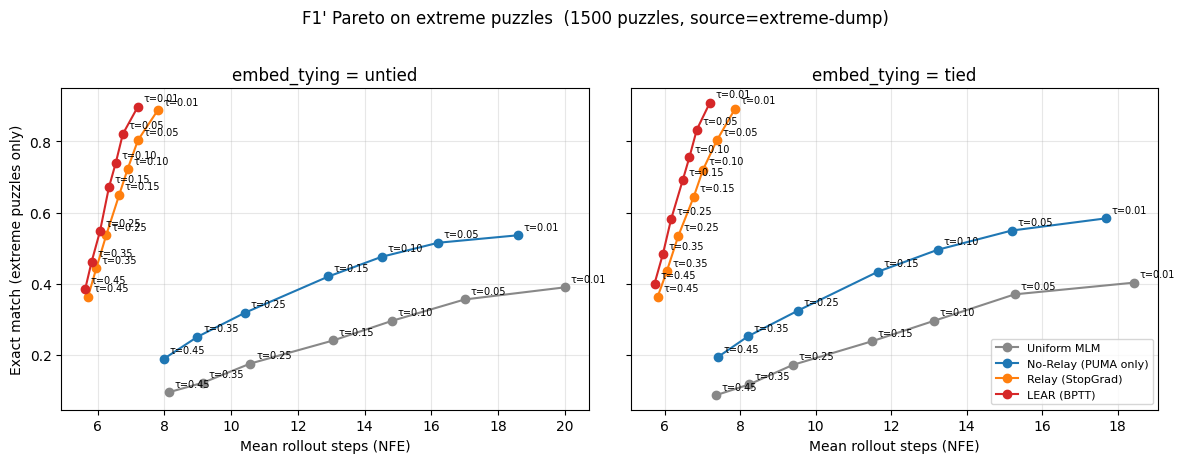

,objective,embed_tying,tau,exact_match,rollout_steps,n
0,mlm_uniform,tied,0.01,0.403000,18.441667,3000
1,mlm_uniform,tied,0.05,0.370000,15.272667,3000
2,mlm_uniform,tied,0.10,0.295667,13.140000,3000
3,mlm_uniform,tied,0.15,0.238333,11.502333,3000
4,mlm_uniform,tied,0.25,0.171667,9.398000,3000
5,mlm_uniform,tied,0.35,0.116667,8.241333,3000
6,mlm_uniform,tied,0.45,0.086667,7.368333,3000
7,mlm_uniform,untied,0.01,0.389778,20.005111,4500
8,mlm_uniform,untied,0.05,0.355556,16.995111,4500
9,mlm_uniform,untied,0.10,0.295778,14.830667,4500


In [4]:
agg = (
    df_hard.groupby(['objective', 'embed_tying', 'tau'], observed=True)
    .agg(exact_match=('exact_match', 'mean'),
         rollout_steps=('rollout_steps', 'mean'),
         n=('exact_match', 'size'))
    .reset_index()
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, tying in zip(axes, ['untied', 'tied']):
    sub = agg[agg['embed_tying'] == tying]
    for obj in OBJECTIVE_ORDER:
        s = sub[sub['objective'] == obj].sort_values('tau')
        if s.empty:
            continue
        ax.plot(s['rollout_steps'], s['exact_match'], 'o-',
                color=OBJECTIVE_COLOR[obj], label=OBJECTIVE_LABEL[obj])
        for _, row in s.iterrows():
            ax.annotate(f'\u03c4={row["tau"]:.2f}',
                        (row['rollout_steps'], row['exact_match']),
                        textcoords='offset points', xytext=(4, 4), fontsize=7)
    ax.set_xlabel('Mean rollout steps (NFE)')
    ax.set_title(f'embed_tying = {tying}')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Exact match (extreme puzzles only)')
axes[1].legend(loc='lower right', fontsize=8)
fig.suptitle(
    f"F1' Pareto on extreme puzzles  ({n_puzzles_hard} puzzles, source={SOURCE})",
    y=1.02,
)
fig.tight_layout()
fig.savefig(FIGS / 'F1p_pareto_extreme.png', dpi=180, bbox_inches='tight')
plt.show()
agg

## F2' — paired Δ (BPTT − StopGrad), per-puzzle, per-seed

Per-puzzle paired Δ with bootstrap 95% CIs. Same construction as the hard
notebook; pair on `(puzzle_hash, embed_tying, seed)` at fixed τ. The expected
ordering, given the hard-cohort gradient, is:

- BPTT − StopGrad: ≥ +6 pp (was +5 pp on hard)
- BPTT − No-Relay: ≥ +25 pp (was +26 pp on hard)
- StopGrad − No-Relay: ≥ +20 pp (was +21 pp on hard)

Paired Δ EM at τ=0.15 on hard cohort:
                        A                         B  n_pairs  mean_delta  ci_lo  ci_hi  p_paired_t
     puma_loopholing_bptt puma_loopholing_stop_grad     7500      0.0377 0.0253 0.0497         0.0
     puma_loopholing_bptt        puma_no_loopholing     9000      0.2536 0.2408 0.2659         0.0
puma_loopholing_stop_grad        puma_no_loopholing     7500      0.2220 0.2076 0.2361         0.0


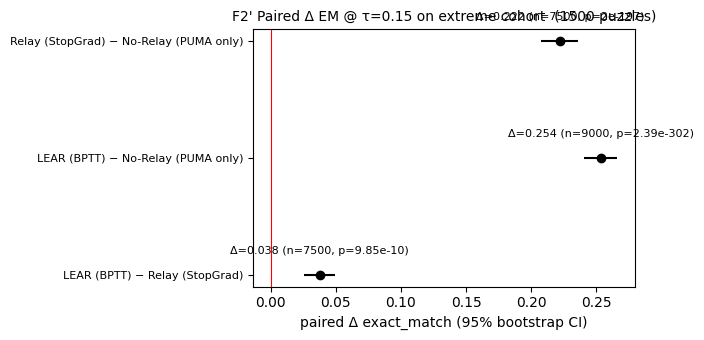

,A,B,n_pairs,mean_delta,ci_lo,ci_hi,p_paired_t
0,puma_loopholing_bptt,puma_loopholing_stop_grad,7500,0.037733,0.025333,0.049733,9.854578e-10
1,puma_loopholing_bptt,puma_no_loopholing,9000,0.253556,0.240778,0.265889,2.389421e-302
2,puma_loopholing_stop_grad,puma_no_loopholing,7500,0.222000,0.207600,0.236143,1.995287e-197


In [5]:
def paired_delta_em(df_in: pd.DataFrame, A: str, B: str, tau: float) -> pd.DataFrame:
    """Per-puzzle paired delta of exact_match for A vs B at a fixed tau.

    Returns one row per (puzzle_hash, embed_tying, seed).
    """
    sub = df_in[df_in['tau'] == tau].copy()
    cols = ['puzzle_hash', 'embed_tying', 'seed', 'objective']
    pivoted = (
        sub.groupby(cols, observed=True)['exact_match']
        .mean()
        .unstack('objective')
    )
    if A not in pivoted.columns or B not in pivoted.columns:
        return pd.DataFrame()
    out = pivoted[[A, B]].dropna(subset=[A, B]).reset_index()
    out['delta'] = out[A].astype(float) - out[B].astype(float)
    out = out.rename(columns={A: f'em_{A}', B: f'em_{B}'})
    return out


def bootstrap_mean_ci(x: np.ndarray, n_boot: int = 2000, alpha: float = 0.05,
                     rng: np.random.Generator | None = None):
    rng = rng or np.random.default_rng(0)
    if len(x) == 0:
        return float('nan'), float('nan'), float('nan')
    means = np.empty(n_boot)
    n = len(x)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        means[i] = x[idx].mean()
    return float(x.mean()), float(np.quantile(means, alpha / 2)), float(np.quantile(means, 1 - alpha / 2))

TARGET_TAU = 0.15
rng = np.random.default_rng(0)

rows = []
for A, B in [
    ('puma_loopholing_bptt', 'puma_loopholing_stop_grad'),
    ('puma_loopholing_bptt', 'puma_no_loopholing'),
    ('puma_loopholing_stop_grad', 'puma_no_loopholing'),
]:
    pair = paired_delta_em(df_hard, A, B, TARGET_TAU)
    if pair.empty:
        rows.append({'A': A, 'B': B, 'n_pairs': 0,
                     'mean_delta': float('nan'), 'ci_lo': float('nan'), 'ci_hi': float('nan'),
                     'p_paired_t': float('nan')})
        continue
    deltas = pair['delta'].values.astype(float)
    m, lo, hi = bootstrap_mean_ci(deltas, n_boot=2000, rng=rng)
    from scipy import stats
    t_p = stats.ttest_1samp(deltas, 0.0).pvalue if len(deltas) > 1 else float('nan')
    rows.append({
        'A': A, 'B': B, 'n_pairs': len(deltas),
        'mean_delta': m, 'ci_lo': lo, 'ci_hi': hi,
        'p_paired_t': t_p,
    })

paired_summary = pd.DataFrame(rows)
print(f'Paired Δ EM at τ={TARGET_TAU} on hard cohort:')
print(paired_summary.round(4).to_string(index=False))

if not paired_summary.empty and paired_summary['n_pairs'].sum() > 0:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    yticks = []
    for i, r in paired_summary.iterrows():
        label = f"{OBJECTIVE_LABEL.get(r['A'], r['A'])} − {OBJECTIVE_LABEL.get(r['B'], r['B'])}"
        yticks.append(label)
        if pd.notna(r['mean_delta']):
            ax.errorbar(
                [r['mean_delta']], [i],
                xerr=[[r['mean_delta'] - r['ci_lo']], [r['ci_hi'] - r['mean_delta']]],
                fmt='o', color='black',
            )
            ax.text(r['mean_delta'], i + 0.18,
                    f"Δ={r['mean_delta']:.3f} (n={int(r['n_pairs'])}, p={r['p_paired_t']:.3g})",
                    fontsize=8, ha='center')
    ax.axvline(0, color='red', linewidth=0.8)
    ax.set_yticks(range(len(yticks)))
    ax.set_yticklabels(yticks, fontsize=8)
    ax.set_xlabel('paired Δ exact_match (95% bootstrap CI)')
    ax.set_title(
        f"F2' Paired Δ EM @ τ={TARGET_TAU} on extreme cohort  ({n_puzzles_hard} puzzles)",
        fontsize=10,
    )
    fig.tight_layout()
    fig.savefig(FIGS / 'F2p_paired_delta_extreme.png', dpi=180, bbox_inches='tight')
    plt.show()
paired_summary

## F4' — legality, *tier-stratified*

Two views of the same data:

1. **Aggregate** (top): mean violations + final legality rate by objective on
   the whole extreme cohort.
2. **Tier-stratified** (bottom): final-board legality rate by `hardest_strategy`
   tier, so we can tell whether BPTT's legality advantage actually widens with
   difficulty (we expected this in the hard study but only got +1 pp; here is
   where it should pop if it's real).

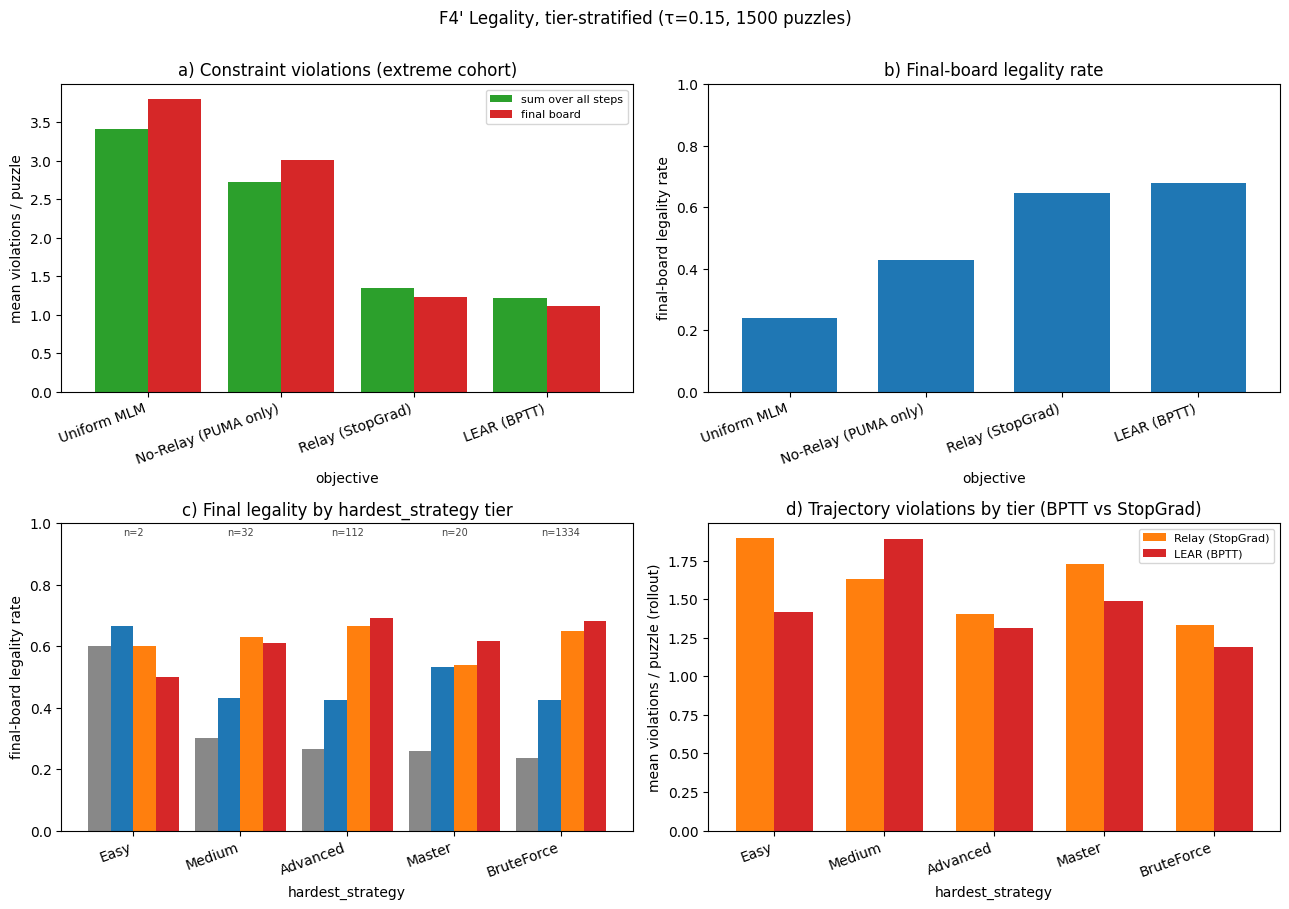

Mean violations (aggregate):
                           violations_total_steps  final_violations
objective                                                          
mlm_uniform                                 3.418             3.804
puma_no_loopholing                          2.719             3.009
puma_loopholing_stop_grad                   1.351             1.233
puma_loopholing_bptt                        1.220             1.109

Final-board legality rate (aggregate):
objective
mlm_uniform                  0.240
puma_no_loopholing           0.427
puma_loopholing_stop_grad    0.647
puma_loopholing_bptt         0.680
Name: _legal, dtype: float64

Final-board legality rate by tier:
objective         mlm_uniform  puma_no_loopholing  puma_loopholing_stop_grad  \
hardest_strategy                                                               
Easy                    0.600               0.667                      0.600   
Medium                  0.300               0.432                   

In [6]:
tau15 = df_hard[df_hard['tau'] == TARGET_TAU].copy()
if tau15.empty:
    print('No rows at tau =', TARGET_TAU)
else:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # (a) Aggregate violations.
    legality = (
        tau15.groupby('objective', observed=True)
        [['violations_total_steps', 'final_violations']]
        .mean()
        .reindex(OBJECTIVE_ORDER)
    )
    legality.plot(kind='bar', ax=axes[0, 0], width=0.8,
                  color=['#2ca02c', '#d62728'])
    axes[0, 0].set_xticklabels([OBJECTIVE_LABEL[o] for o in OBJECTIVE_ORDER],
                               rotation=20, ha='right')
    axes[0, 0].set_ylabel('mean violations / puzzle')
    axes[0, 0].set_title('a) Constraint violations (extreme cohort)')
    axes[0, 0].legend(['sum over all steps', 'final board'], fontsize=8)

    # (b) Aggregate final-board legality rate.
    leg_rate = (
        tau15.assign(_legal=tau15['final_violations'] == 0)
        .groupby('objective', observed=True)['_legal']
        .mean()
        .reindex(OBJECTIVE_ORDER)
    )
    leg_rate.plot(kind='bar', ax=axes[0, 1], width=0.7, color='#1f77b4')
    axes[0, 1].set_xticklabels([OBJECTIVE_LABEL[o] for o in OBJECTIVE_ORDER],
                               rotation=20, ha='right')
    axes[0, 1].set_ylabel('final-board legality rate')
    axes[0, 1].set_title('b) Final-board legality rate')
    axes[0, 1].set_ylim(0, 1)

    # (c) Tier-stratified legality rate (group bars by tier, color by objective).
    leg_by_tier = (
        tau15.assign(_legal=tau15['final_violations'] == 0)
        .groupby(['hardest_strategy', 'objective'], observed=True)['_legal']
        .mean()
        .unstack('objective')
        .reindex(STRATEGY_ORDER)
    )
    obj_present = [o for o in OBJECTIVE_ORDER if o in leg_by_tier.columns]
    keep = leg_by_tier[obj_present].dropna(how='all')
    if not keep.empty:
        keep.plot(kind='bar', ax=axes[1, 0], width=0.85,
                  color=[OBJECTIVE_COLOR[o] for o in obj_present],
                  legend=False)
        axes[1, 0].set_xticklabels(keep.index, rotation=20, ha='right')
        axes[1, 0].set_ylabel('final-board legality rate')
        axes[1, 0].set_ylim(0, 1)
        axes[1, 0].set_title('c) Final legality by hardest_strategy tier')
        # Per-tier puzzle counts above the group.
        tier_counts = (
            tau15.drop_duplicates('puzzle_hash')['hardest_strategy']
            .value_counts()
            .reindex(keep.index, fill_value=0)
        )
        for i, (idx, n) in enumerate(tier_counts.items()):
            axes[1, 0].text(i, 0.96, f'n={int(n)}', ha='center', fontsize=7,
                            color='#444')

    # (d) Tier-stratified mean violations across rollout (BPTT vs StopGrad only).
    viol_by_tier = (
        tau15.groupby(['hardest_strategy', 'objective'], observed=True)
        ['violations_total_steps']
        .mean()
        .unstack('objective')
        .reindex(STRATEGY_ORDER)
    )
    obj_show = ['puma_loopholing_stop_grad', 'puma_loopholing_bptt']
    keep_v = viol_by_tier[[c for c in obj_show if c in viol_by_tier.columns]].dropna(how='all')
    if not keep_v.empty:
        keep_v.plot(kind='bar', ax=axes[1, 1], width=0.7,
                    color=[OBJECTIVE_COLOR[o] for o in keep_v.columns],
                    legend=False)
        axes[1, 1].set_xticklabels(keep_v.index, rotation=20, ha='right')
        axes[1, 1].set_ylabel('mean violations / puzzle (rollout)')
        axes[1, 1].set_title('d) Trajectory violations by tier (BPTT vs StopGrad)')
        axes[1, 1].legend([OBJECTIVE_LABEL[o] for o in keep_v.columns], fontsize=8)

    fig.suptitle(
        f"F4' Legality, tier-stratified (τ={TARGET_TAU}, {n_puzzles_hard} puzzles)",
        y=1.005,
    )
    fig.tight_layout()
    fig.savefig(FIGS / 'F4p_legality_extreme.png', dpi=180, bbox_inches='tight')
    plt.show()
    print('Mean violations (aggregate):')
    print(legality.round(3))
    print('\nFinal-board legality rate (aggregate):')
    print(leg_rate.round(3))
    print('\nFinal-board legality rate by tier:')
    print(leg_by_tier.round(3))

## F3' — solver alignment, paired view

Per-puzzle paired Δ of `fill_order_spearman` and `prefix_jaccard_at_{5,10}`.
We drop `prefix_jaccard_at_20` because most loopholing trajectories never
reach 20 commits (the metric saturates at ~0 on the hard cohort).

If BPTT's hypothesized advantage is whole-trajectory credit assignment, the
paired Δ vs StopGrad should be *bigger* on the extreme cohort than on hard.

In [7]:
def paired_delta_metric(df_in: pd.DataFrame, A: str, B: str, tau: float, metric: str) -> pd.DataFrame:
    sub = df_in[df_in['tau'] == tau].copy()
    cols = ['puzzle_hash', 'embed_tying', 'seed', 'objective']
    pivoted = (
        sub.groupby(cols, observed=True)[metric]
        .mean()
        .unstack('objective')
    )
    if A not in pivoted.columns or B not in pivoted.columns:
        return pd.DataFrame()
    out = pivoted[[A, B]].dropna(subset=[A, B]).reset_index()
    out['delta'] = out[A].astype(float) - out[B].astype(float)
    return out

rows = []
for metric in ['fill_order_spearman', 'prefix_jaccard_at_5',
               'prefix_jaccard_at_10']:
    for A, B in [
        ('puma_loopholing_bptt', 'puma_loopholing_stop_grad'),
        ('puma_loopholing_bptt', 'puma_no_loopholing'),
    ]:
        pair = paired_delta_metric(df_hard, A, B, TARGET_TAU, metric)
        if pair.empty:
            continue
        deltas = pair['delta'].dropna().values.astype(float)
        if len(deltas) < 2:
            continue
        m, lo, hi = bootstrap_mean_ci(deltas, n_boot=2000,
                                       rng=np.random.default_rng(0))
        rows.append({'metric': metric,
                     'pair': f"{OBJECTIVE_LABEL[A]} − {OBJECTIVE_LABEL[B]}",
                     'n_pairs': int(len(deltas)),
                     'mean': m, 'ci_lo': lo, 'ci_hi': hi})
align_summary = pd.DataFrame(rows)
if not align_summary.empty:
    print("F3' paired-Δ alignment metrics (extreme cohort, τ={:.2f}):".format(TARGET_TAU))
    print(align_summary.round(4).to_string(index=False))
else:
    print('No alignment data available.')

F3' paired-Δ alignment metrics (extreme cohort, τ=0.15):
              metric                               pair  n_pairs    mean   ci_lo   ci_hi
 fill_order_spearman     LEAR (BPTT) − Relay (StopGrad)     6545  0.0067  0.0043  0.0091
 fill_order_spearman LEAR (BPTT) − No-Relay (PUMA only)     7854  0.0397  0.0371  0.0423
 prefix_jaccard_at_5     LEAR (BPTT) − Relay (StopGrad)     7500  0.0058  0.0022  0.0094
 prefix_jaccard_at_5 LEAR (BPTT) − No-Relay (PUMA only)     9000 -0.0259 -0.0348 -0.0171
prefix_jaccard_at_10     LEAR (BPTT) − Relay (StopGrad)     7500  0.0022  0.0008  0.0036
prefix_jaccard_at_10 LEAR (BPTT) − No-Relay (PUMA only)     9000  0.1060  0.1004  0.1118


## Coverage-gated matched-NFE

Same construction as the hard notebook. The only B with high coverage for both
loopholing models on the hard cohort was 6.0; we expect the same here. Treat
any (model, tying, B) cell with coverage < 0.6 as interpolation-bias-dominated
and ignore it.

In [8]:
def matched_nfe(df_in: pd.DataFrame, metric_col: str, B: float, eps: float = 1.5) -> pd.DataFrame:
    rows = []
    for (obj, tying), sub in df_in.groupby(['objective', 'embed_tying'], observed=True):
        for ph, g in sub.groupby('puzzle_hash'):
            if g[metric_col].isna().all():
                continue
            xs = g['rollout_steps'].astype(float).values
            ys = g[metric_col].astype(float).values
            order = np.argsort(xs)
            xs = xs[order]; ys = ys[order]
            if not ((xs.min() - eps) <= B <= (xs.max() + eps)):
                continue
            rows.append({'objective': obj, 'embed_tying': tying,
                         'puzzle_hash': ph, metric_col: float(np.interp(B, xs, ys))})
    return pd.DataFrame(rows)

nfe_obs = (
    df_hard.groupby(['objective', 'embed_tying', 'tau'], observed=True)['rollout_steps']
    .mean()
)
B_grid = np.linspace(float(nfe_obs.min()), float(nfe_obs.max()), 5).round(1).tolist()
print('B grid:', B_grid)
for B in B_grid:
    em = matched_nfe(df_hard, 'exact_match', B)
    if em.empty:
        continue
    summary = (em.groupby(['objective', 'embed_tying'], observed=True)['exact_match']
               .agg(['mean', 'count'])
               .rename(columns={'mean': f'em@NFE={B}', 'count': f'n@NFE={B}'}))
    coverage = summary[f'n@NFE={B}'] / n_puzzles_hard
    print(f'\n=== matched NFE = {B} ({n_puzzles_hard} extreme puzzles total) ===')
    print(summary.unstack('embed_tying'))
    print('coverage:')
    print(coverage.unstack('embed_tying').round(2))
    if (coverage < 0.6).any():
        print('** WARNING: at least one (objective, tying) has coverage < 0.6; **'
              ' the matched-NFE EM at this B is selection-biased toward late-failing puzzles.')

B grid: [5.6, 9.2, 12.8, 16.4, 20.0]

=== matched NFE = 5.6 (1500 extreme puzzles total) ===
                          em@NFE=5.6           n@NFE=5.6       
embed_tying                     tied    untied      tied untied
objective                                                      
mlm_uniform                 0.177461  0.193720      1158   1051
puma_loopholing_bptt        0.662853  0.627923      1451   1454
puma_loopholing_stop_grad   0.674965  0.637500      1442   1456
puma_no_loopholing          0.336087  0.326115      1247   1099
coverage:
embed_tying                tied  untied
objective                              
mlm_uniform                0.77    0.70
puma_loopholing_bptt       0.97    0.97
puma_loopholing_stop_grad  0.96    0.97
puma_no_loopholing         0.83    0.73

=== matched NFE = 9.2 (1500 extreme puzzles total) ===
                          em@NFE=9.2           n@NFE=9.2       
embed_tying                     tied    untied      tied untied
objective                


=== matched NFE = 20.0 (1500 extreme puzzles total) ===
                          em@NFE=20.0           n@NFE=20.0       
embed_tying                      tied    untied       tied untied
objective                                                        
mlm_uniform                  0.155260  0.198408        799   1008
puma_loopholing_bptt         0.009956  0.015177        113    139
puma_loopholing_stop_grad    0.021595  0.012827        128    169
puma_no_loopholing           0.306734  0.301899        872    976
coverage:
embed_tying                tied  untied
objective                              
mlm_uniform                0.53    0.67
puma_loopholing_bptt       0.08    0.09
puma_loopholing_stop_grad  0.09    0.11
puma_no_loopholing         0.58    0.65
** WARNING: at least one (objective, tying) has coverage < 0.6; ** the matched-NFE EM at this B is selection-biased toward late-failing puzzles.


## Per-stratum table — the headline figure

Same three strata as `sudoku_hard_only_study.ipynb`, but now the Master count
should be in the hundreds instead of 6:

1. **heuristic-Advanced** (Advanced tier, no Brute Force): naked/hidden pairs,
   triples, quads. Pure strategy-reasoning.
2. **heuristic-Master** (Master tier, no Brute Force): X-Wings, Swordfish,
   Jellyfish, Forcing Chains. The puzzles that *need* multi-cell lookahead.
3. **BF-rating-tail**: BruteForce puzzles whose rating is at or above the
   median of the BF-tier-only rating distribution within the cohort. These are
   the deep-lookahead BF puzzles.

In addition to per-objective EM, also report the **paired Δ (BPTT − StopGrad)
within each stratum** so we can put a CI on the Master result that was n=6
last time.

In [9]:
def _has_bf(strats):
    if strats is None:
        return False
    try:
        return 'Brute Force' in list(strats)
    except TypeError:
        return False

df_hard['_has_bf'] = df_hard['strategies_used'].apply(_has_bf)
is_adv = (df_hard['hardest_strategy'] == 'Advanced') & (~df_hard['_has_bf'])
is_master = (df_hard['hardest_strategy'] == 'Master') & (~df_hard['_has_bf'])
is_bf = df_hard['hardest_strategy'] == 'BruteForce'
rating_med_bf = float(df_hard.loc[is_bf, 'rating'].median()) if is_bf.any() else float('nan')
is_bf_tail = is_bf & (df_hard['rating'] >= rating_med_bf)

strata = {
    'heuristic-Advanced': is_adv,
    'heuristic-Master': is_master,
    f'BF-rating-tail (rating>={rating_med_bf:.0f})': is_bf_tail,
}
rows = []
for name, mask in strata.items():
    sub = df_hard[mask & (df_hard['tau'] == TARGET_TAU)]
    if sub.empty:
        rows.append({'stratum': name, 'n_puzzles': 0})
        continue
    em = (sub.groupby('objective', observed=True)['exact_match']
          .mean()
          .reindex(OBJECTIVE_ORDER))
    # Paired BPTT - StopGrad within the stratum, with bootstrap CI.
    bptt_vs_sg = paired_delta_em(
        df_hard[mask], 'puma_loopholing_bptt', 'puma_loopholing_stop_grad', TARGET_TAU,
    )
    if bptt_vs_sg.empty:
        delta_str = 'n/a'
        n_pairs = 0
    else:
        deltas = bptt_vs_sg['delta'].values.astype(float)
        m, lo, hi = bootstrap_mean_ci(deltas, n_boot=2000,
                                       rng=np.random.default_rng(0))
        delta_str = f'{m:+.3f} [{lo:+.3f}, {hi:+.3f}]'
        n_pairs = int(len(deltas))
    rows.append({
        'stratum': name,
        'n_puzzles': sub['puzzle_hash'].nunique(),
        **{f'EM:{OBJECTIVE_LABEL[o]}': float(em.get(o, np.nan)) for o in OBJECTIVE_ORDER},
        'paired Δ (BPTT-SG) [95% CI]': delta_str,
        'n_pairs(BPTT-SG)': n_pairs,
    })
stratum_summary = pd.DataFrame(rows)
print(f'Per-stratum exact match @ τ={TARGET_TAU} (extreme cohort):')
print(stratum_summary.round(3).to_string(index=False))

Per-stratum exact match @ τ=0.15 (extreme cohort):
                   stratum  n_puzzles  EM:Uniform MLM  EM:No-Relay (PUMA only)  EM:Relay (StopGrad)  EM:LEAR (BPTT) paired Δ (BPTT-SG) [95% CI]  n_pairs(BPTT-SG)
        heuristic-Advanced        112           0.264                    0.424                0.664           0.690     +0.029 [-0.016, +0.075]               560
          heuristic-Master         20           0.260                    0.533                0.540           0.617     +0.070 [-0.020, +0.170]               100
BF-rating-tail (rating>=3)        676           0.196                    0.397                0.654           0.697     +0.046 [+0.029, +0.063]              3380
